# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete Deep Learning pipeline by reading the markdown and running the ready-to-use code.

---

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Validation curves
- Generalization ability
- Training strategies (dropout, batch norm, augmentation)

---

### 📦 CIFAR-10 Classes
The dataset has 10 categories:

| Label | Class |
|-------|-------|
| 0 | Airplane |
| 1 | Automobile |
| 2 | Bird |
| 3 | Cat |
| 4 | Deer |
| 5 | Dog |
| 6 | Frog |
| 7 | Horse |
| 8 | Ship |
| 9 | Truck |

## 📦 Step 1: Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


---

## 📥 Step 2: Load the CIFAR-10 Dataset

CIFAR-10 contains **60,000 color images** of size **32×32×3** (RGB).
- **50,000 images** → training
- **10,000 images** → testing

Keras downloads it automatically the first time.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training images shape :", x_train.shape)   # (50000, 32, 32, 3)
print("Training labels shape :", y_train.shape)   # (50000, 1)
print("Test images shape     :", x_test.shape)    # (10000, 32, 32, 3)
print("Test labels shape     :", y_test.shape)    # (10000, 1)
print("Pixel value range     :", x_train.min(), "to", x_train.max())

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000, 1)
Test images shape     : (10000, 32, 32, 3)
Test labels shape     : (10000, 1)
Pixel value range     : 0 to 255


## 🖼️ Step 3: Visualize Sample Images
Let's see what the images actually look like. Each image is only 32×32 pixels.

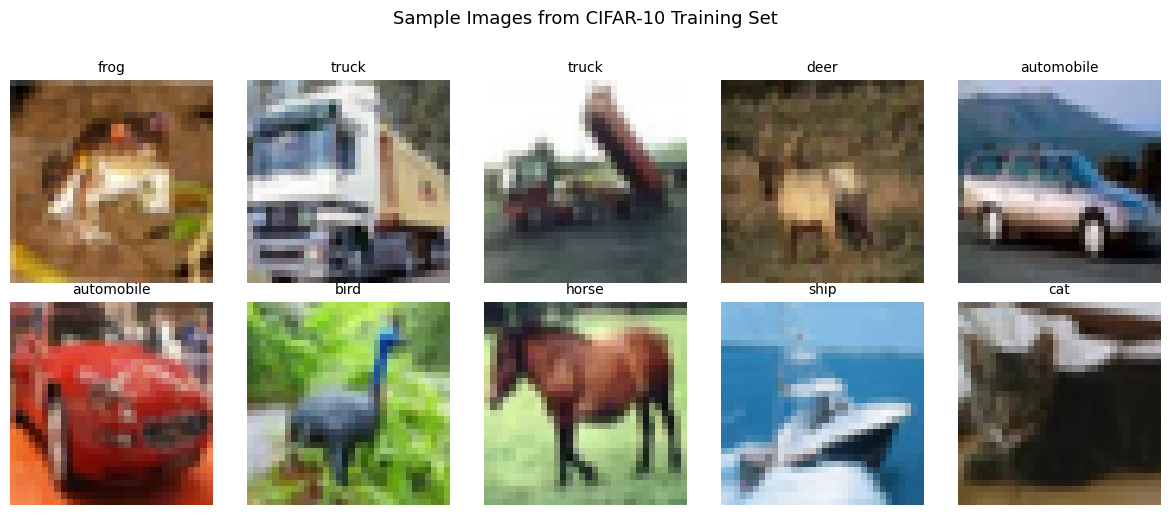

In [3]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=10)
    plt.axis('off')
plt.suptitle('Sample Images from CIFAR-10 Training Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 🧹 Step 4: Normalize the Pixel Values

**Why normalize?**
- Raw pixels are integers from 0 to 255
- Large values can make gradients explode during training
- Dividing by 255 scales everything to the range **0.0 – 1.0**
- This makes the optimizer (Adam) work much more efficiently

We also create a **flattened version** for the ANN which cannot use 2D grids.

In [4]:
# Normalize: 0-255 integers  →  0.0-1.0 floats
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

# Flatten: (50000, 32, 32, 3)  →  (50000, 3072) for ANN input
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm),  -1)

print("Normalized pixel range :", x_train_norm.min(), "to", x_train_norm.max())
print("Flat shape for ANN     :", x_train_flat.shape)   # 32*32*3 = 3072

Normalized pixel range : 0.0 to 1.0
Flat shape for ANN     : (50000, 3072)


---

# 🔹 Part 1: ANN Model (Artificial Neural Network)

**How ANN sees an image:**
- It takes the flattened vector (3072 numbers)
- It passes them through fully connected (Dense) layers
- It cannot see spatial patterns — pixels lose their 2D position
- This is why ANN is less accurate on images compared to CNN

### Architecture:
```
Input (3072)  →  Dense(512)  →  Dropout(0.3)  →  Dense(256)  →  Dense(10)
```

In [5]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN_Model')

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
print("Training ANN for 10 epochs...")

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Training ANN for 10 epochs...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.2719 - loss: 1.9877 - val_accuracy: 0.3192 - val_loss: 1.8593
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3154 - loss: 1.8806 - val_accuracy: 0.3520 - val_loss: 1.8075
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3350 - loss: 1.8206 - val_accuracy: 0.3580 - val_loss: 1.7672
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.3528 - loss: 1.7775 - val_accuracy: 0.3818 - val_loss: 1.7352
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3659 - loss: 1.7468 - val_accuracy: 0.4042 - val_loss: 1.6827
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3739 - loss: 1.7227 - val_accuracy: 0.3822 - val_loss: 1.6931
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.3833 - loss: 1.7038 - val_accuracy: 0.4104 - val_loss: 1.6486
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accu

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN  →  Test Loss: {ann_test_loss:.4f}  |  Test Accuracy: {ann_test_acc:.4f} ({ann_test_acc*100:.2f}%)")

ANN  →  Test Loss: 1.6143  |  Test Accuracy: 0.4323 (43.23%)


---

# 🔹 Part 2: CNN Model (Convolutional Neural Network)


**How CNN sees an image:**
- Conv2D layers scan the image using small filters (e.g. 3×3)
- They detect edges, textures, and patterns in 2D space
- BatchNormalization stabilizes training between layers
- MaxPooling2D reduces size while keeping important features
- Flatten then connects to Dense classification layers

### Architecture:
```
Input (32,32,3)
→ Conv2D(32) + BatchNorm + MaxPool
→ Conv2D(64) + BatchNorm + MaxPool
→ Conv2D(128)
→ Flatten
→ Dense(128) + Dropout(0.4)
→ Dense(10)   [output]
```

In [8]:
cnn_model = models.Sequential([
    # Block 1 — detect basic edges and colors
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — detect shapes and textures
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — detect complex patterns
    layers.Conv2D(128, (3, 3), activation='relu'),

    # Flatten and classify
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Model')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

In [9]:
print("Training CNN for 10 epochs...")

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Training CNN for 10 epochs...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 75ms/step - accuracy: 0.4595 - loss: 1.5200 - val_accuracy: 0.5132 - val_loss: 1.4528
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.5972 - loss: 1.1533 - val_accuracy: 0.6328 - val_loss: 1.0649
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.6570 - loss: 0.9809 - val_accuracy: 0.6616 - val_loss: 0.9590
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 75ms/step - accuracy: 0.6986 - loss: 0.8620 - val_accuracy: 0.6344 - val_loss: 1.0285
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.7291 - loss: 0.7748 - val_accuracy: 0.6520 - val_loss: 1.0622
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 78ms/step - accuracy: 0.7594 - loss: 0.6874 - val_accuracy: 0.7150 - val_loss: 0.8293
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 79ms/step - accuracy: 0.7810 - loss: 0.6169 - val_accuracy: 0.7208 - val_loss: 0.8537
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accu

In [10]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN  →  Test Loss: {cnn_test_loss:.4f}  |  Test Accuracy: {cnn_test_acc:.4f} ({cnn_test_acc*100:.2f}%)")

CNN  →  Test Loss: 1.0232  |  Test Accuracy: 0.6847 (68.47%)


---

## 📈 Step 5: Compare Validation Accuracy Curves (ANN vs CNN)

Plotting both models on one chart lets us visually see:
- How fast each model improves per epoch
- Which model generalizes better on unseen validation data
- The accuracy gap between ANN and CNN

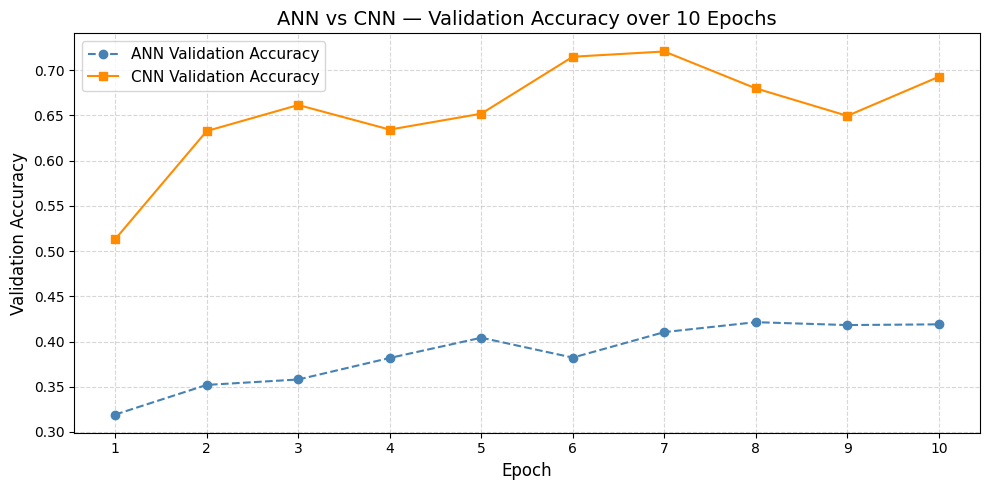

In [11]:
epochs_range = range(1, 11)

plt.figure(figsize=(10, 5))

plt.plot(epochs_range, ann_history.history['val_accuracy'],
         label='ANN Validation Accuracy', marker='o', linestyle='--', color='steelblue')

plt.plot(epochs_range, cnn_history.history['val_accuracy'],
         label='CNN Validation Accuracy', marker='s', linestyle='-', color='darkorange')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('ANN vs CNN — Validation Accuracy over 10 Epochs', fontsize=14)
plt.legend(fontsize=11)
plt.xticks(epochs_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---

## 📊 Step 6: Final Comparison Table

A side-by-side look at how both models scored on the **test set** (data the model never saw during training).

In [12]:
comparison_df = pd.DataFrame({
    'Model'         : ['ANN', 'CNN'],
    'Test Accuracy' : [round(ann_test_acc, 4), round(cnn_test_acc, 4)],
    'Test Loss'     : [round(ann_test_loss, 4), round(cnn_test_loss, 4)],
    'Accuracy (%)'  : [round(ann_test_acc * 100, 2), round(cnn_test_acc * 100, 2)]
})

print(comparison_df.to_string(index=False))

Model  Test Accuracy  Test Loss  Accuracy (%)
  ANN         0.4323     1.6143         43.23
  CNN         0.6847     1.0232         68.47


---

# 🚀 Part 3: Data Augmentation CNN

**What is Data Augmentation?**
It artificially creates new training samples by randomly transforming existing images:
- `RandomFlip` — mirrors the image horizontally
- `RandomRotation` — rotates slightly (10% of 360° = ~36 degrees max)
- `RandomZoom` — zooms in/out by up to 10%

**Why does this help?**
The model sees more variety and learns features that are **rotation/flip invariant**, which reduces overfitting and improves real-world generalization.

This augmentation layer is built **inside the model** so transformations happen automatically during training.

In [13]:
# Define augmentation pipeline — applied only during training, not during evaluation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='Data_Augmentation')

# Build the augmented CNN
aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='Augmented_CNN')

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "Augmented_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Data_Augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
print("Training Augmented CNN for 10 epochs...")

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Aug CNN  →  Test Loss: {aug_test_loss:.4f}  |  Test Accuracy: {aug_test_acc:.4f} ({aug_test_acc*100:.2f}%)")

Training Augmented CNN for 10 epochs...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 72ms/step - accuracy: 0.3821 - loss: 1.7376 - val_accuracy: 0.4730 - val_loss: 1.4520
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.4716 - loss: 1.4808 - val_accuracy: 0.4480 - val_loss: 1.6622
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.5119 - loss: 1.3742 - val_accuracy: 0.5716 - val_loss: 1.2081
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.5434 - loss: 1.2876 - val_accuracy: 0.6050 - val_loss: 1.1231
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.5626 - loss: 1.2441 - val_accuracy: 0.5480 - val_loss: 1.2986
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 79ms/step - accuracy: 0.5810 - loss: 1.1995 - val_accuracy: 0.5976 - val_loss: 1.1154
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 75ms/step - accuracy: 0.5876 - loss: 1.1692 - val_accuracy: 0.6368 - val_loss: 1.0198
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/s

---

# 🎓 Student Learning Tasks — Fully Implemented

These tasks are meant to help you go beyond the basics. Each one is explained and coded below.

---

### ✅ Task 1: Increase ANN Dense Layers and Observe Performance

We add one more hidden Dense layer to give the ANN more capacity to learn.  
Adding layers allows the model to learn more complex patterns — but it also trains slower and may overfit.

In [15]:
# Task 1 — Deeper ANN with 3 hidden layers instead of 2
ann_deep = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),   # extra layer added here
    layers.Dense(10, activation='softmax')
], name='ANN_Deep')

ann_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training deeper ANN...")
ann_deep_history = ann_deep.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

deep_ann_loss, deep_ann_acc = ann_deep.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nOriginal ANN accuracy : {ann_test_acc:.4f}")
print(f"Deeper ANN accuracy   : {deep_ann_acc:.4f}")

Training deeper ANN...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.2378 - loss: 2.0393 - val_accuracy: 0.2900 - val_loss: 1.9312
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.2945 - loss: 1.9021 - val_accuracy: 0.3140 - val_loss: 1.8746
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3069 - loss: 1.8689 - val_accuracy: 0.3532 - val_loss: 1.8146
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3227 - loss: 1.8352 - val_accuracy: 0.3600 - val_loss: 1.8015
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3312 - loss: 1.8151 - val_accuracy: 0.3568 - val_loss: 1.7803
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3405 - loss: 1.7984 - val_accuracy: 0.3842 - val_loss: 1.7226
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3446 - loss: 1.7800 - val_accuracy: 0.3780 - val_loss: 1.7440
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0

---

### ✅ Task 2: Scale CNN Filters 32 → 64 → 128

The original CNN already uses this pattern.  
Here we confirm and annotate **why** we increase filter count per block:
- **32 filters** in block 1 → detects low-level features (edges, gradients)
- **64 filters** in block 2 → detects mid-level features (corners, shapes)
- **128 filters** in block 3 → detects high-level features (object parts)

More filters = more feature detectors = better learning of complex patterns.

In [16]:
# Task 2 — Explicitly show 32 → 64 → 128 filter scaling
cnn_scaled = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),   # 32 filters
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),                            # 64 filters
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),                           # 128 filters

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Scaled_Filters')

cnn_scaled.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Filter sizes per conv block: 32 → 64 → 128")
cnn_scaled.summary()

Filter sizes per conv block: 32 → 64 → 128


Model: "CNN_Scaled_Filters"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

---

### ✅ Task 3: Train for 20 Epochs

More epochs = more passes through the training data.  
The model gets more chances to update its weights and improve accuracy.  
However, too many epochs without EarlyStopping can cause **overfitting** — the model memorizes training data but fails on test data.

In [17]:
# Task 3 — Train the scaled CNN for 20 epochs
print("Training CNN for 20 epochs...")

history_20ep = cnn_scaled.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

loss_20ep, acc_20ep = cnn_scaled.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n20-epoch CNN  →  Test Accuracy: {acc_20ep:.4f} ({acc_20ep*100:.2f}%)")

Training CNN for 20 epochs...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 73ms/step - accuracy: 0.4629 - loss: 1.5002 - val_accuracy: 0.5276 - val_loss: 1.3799
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.6087 - loss: 1.1279 - val_accuracy: 0.4580 - val_loss: 1.6413
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.6680 - loss: 0.9559 - val_accuracy: 0.6746 - val_loss: 0.9335
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 78ms/step - accuracy: 0.7073 - loss: 0.8399 - val_accuracy: 0.6332 - val_loss: 1.0910
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 80ms/step - accuracy: 0.7392 - loss: 0.7487 - val_accuracy: 0.6548 - val_loss: 1.1524
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 80ms/step - accuracy: 0.7639 - loss: 0.6723 - val_accuracy: 0.7200 - val_loss: 0.8386
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 78ms/step - accuracy: 0.7861 - loss: 0.6051 - val_accuracy: 0.7334 - val_loss: 0.8160
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 78ms/step - accu

---

### ✅ Task 4: Add EarlyStopping

**EarlyStopping** is a callback that stops training automatically when performance stops improving.  

- `monitor='val_loss'` — watches validation loss
- `patience=4` — waits 4 extra epochs before stopping, in case it improves
- `restore_best_weights=True` — rolls back to the best weights seen during training

This saves compute time and prevents overfitting.

In [18]:
# Task 4 — CNN with EarlyStopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

cnn_es_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_EarlyStopping')

cnn_es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training with EarlyStopping (max 20 epochs)...")
history_es = cnn_es_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

es_loss, es_acc = cnn_es_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nEarlyStopping CNN  →  Stopped at epoch {len(history_es.epoch)}")
print(f"Test Accuracy      →  {es_acc:.4f} ({es_acc*100:.2f}%)")

Training with EarlyStopping (max 20 epochs)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 75ms/step - accuracy: 0.4598 - loss: 1.5176 - val_accuracy: 0.4922 - val_loss: 1.4727
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.6059 - loss: 1.1232 - val_accuracy: 0.5346 - val_loss: 1.3622
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 76ms/step - accuracy: 0.6701 - loss: 0.9496 - val_accuracy: 0.6404 - val_loss: 1.0288
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.7127 - loss: 0.8262 - val_accuracy: 0.6850 - val_loss: 0.9131
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 74ms/step - accuracy: 0.7435 - loss: 0.7390 - val_accuracy: 0.6830 - val_loss: 0.9369
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 71ms/step - accuracy: 0.7671 - loss: 0.6602 - val_accuracy: 0.6108 - val_loss: 1.2945
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.7914 - loss: 0.5956 - val_accuracy: 0.7414 - val_loss: 0.8020
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s

---

### ✅ Task 5: Full Data Augmentation Training Run

This is the most complete version of our CNN:
- Data augmentation (RandomFlip, RandomRotation, RandomZoom)
- Scaled filters (32 → 64 → 128)
- BatchNormalization
- EarlyStopping
- 20 epochs maximum

This combination typically gives the best generalization on test data.

In [19]:
# Task 5 — Complete augmented model with all upgrades

augmentation_layer = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

full_aug_model = models.Sequential([
    augmentation_layer,

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='Full_Augmented_CNN')

full_aug_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_aug = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

print("Training Full Augmented CNN (up to 20 epochs with EarlyStopping)...")
full_aug_history = full_aug_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug],
    verbose=1
)

full_aug_loss, full_aug_acc = full_aug_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nFull Augmented CNN  →  Test Accuracy: {full_aug_acc:.4f} ({full_aug_acc*100:.2f}%)")

Training Full Augmented CNN (up to 20 epochs with EarlyStopping)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 83ms/step - accuracy: 0.4158 - loss: 1.7359 - val_accuracy: 0.5464 - val_loss: 1.2828
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.5210 - loss: 1.3562 - val_accuracy: 0.5154 - val_loss: 1.5242
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 82ms/step - accuracy: 0.5626 - loss: 1.2428 - val_accuracy: 0.6026 - val_loss: 1.1476
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.5901 - loss: 1.1643 - val_accuracy: 0.6004 - val_loss: 1.1463
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.6143 - loss: 1.1010 - val_accuracy: 0.6304 - val_loss: 1.0671
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.6302 - loss: 1.0591 - val_accuracy: 0.6684 - val_loss: 0.9832
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 82ms/step - accuracy: 0.6456 - loss: 1.0174 - val_accuracy: 0.6776 - val_loss: 0.9192
Epoch 8/20
704/704 ━━━

---

## 📊 Final Summary: All Model Comparison

Let's put every model we built into one comparison table.

In [20]:
final_comparison = pd.DataFrame({
    'Model'            : ['ANN (Baseline)', 'CNN (Baseline)', 'Augmented CNN', 'Full Aug + EarlyStopping'],
    'Test Accuracy'    : [
                            round(ann_test_acc, 4),
                            round(cnn_test_acc, 4),
                            round(aug_test_acc, 4),
                            round(full_aug_acc, 4)
                         ],
    'Accuracy (%)'     : [
                            round(ann_test_acc * 100, 2),
                            round(cnn_test_acc * 100, 2),
                            round(aug_test_acc * 100, 2),
                            round(full_aug_acc * 100, 2)
                         ]
})

print(final_comparison.to_string(index=False))

                   Model  Test Accuracy  Accuracy (%)
          ANN (Baseline)         0.4323         43.23
          CNN (Baseline)         0.6847         68.47
           Augmented CNN         0.6342         63.42
Full Aug + EarlyStopping         0.7333         73.33


---

# ✅ Conclusion

| Concept | Key Takeaway |
|---------|-------------|
| **ANN** | Treats images as flat numbers — ignores spatial structure |
| **CNN** | Uses convolutions to learn spatial patterns — much better for images |
| **BatchNormalization** | Stabilizes training, allows higher learning rates |
| **Dropout** | Randomly disables neurons to prevent overfitting |
| **Data Augmentation** | Artificially expands the dataset — improves generalization |
| **EarlyStopping** | Stops training when it stops improving — saves time and avoids overfit |
| **Filter Scaling (32→64→128)** | More filters at deeper layers = more complex feature detection |

---

### 🚀 Next Steps to Explore
- Try **ResNet** or **VGG** architectures for even higher accuracy
- Use **Learning Rate Scheduling** to fine-tune how fast the model learns
- Try **Transfer Learning** with pre-trained ImageNet weights
- Visualize what the Conv2D filters actually learned using **feature maps**